In [3]:
#load data
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("HousePricePrediction.csv")

In [7]:
df.shape
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2919 non-null   int64  
 1   MSSubClass    2919 non-null   int64  
 2   MSZoning      2915 non-null   object 
 3   LotArea       2919 non-null   int64  
 4   LotConfig     2919 non-null   object 
 5   BldgType      2919 non-null   object 
 6   OverallCond   2919 non-null   int64  
 7   YearBuilt     2919 non-null   int64  
 8   YearRemodAdd  2919 non-null   int64  
 9   Exterior1st   2918 non-null   object 
 10  BsmtFinSF2    2918 non-null   float64
 11  TotalBsmtSF   2918 non-null   float64
 12  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(6), object(4)
memory usage: 296.6+ KB


,Id,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice
count,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2918.000000,2918.000000,1460.000000
mean,1459.000000,57.137718,10168.114080,5.564577,1971.312778,1984.264474,49.582248,1051.777587,180921.195890
std,842.787043,42.517628,7886.996359,1.113131,30.291442,20.894344,169.205611,440.766258,79442.502883
min,0.000000,20.000000,1300.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,34900.000000
25%,729.500000,20.000000,7478.000000,5.000000,1953.500000,1965.000000,0.000000,793.000000,129975.000000
50%,1459.000000,50.000000,9453.000000,5.000000,1973.000000,1993.000000,0.000000,989.500000,163000.000000
75%,2188.500000,70.000000,11570.000000,6.000000,2001.000000,2004.000000,0.000000,1302.000000,214000.000000
max,2918.000000,190.000000,215245.000000,9.000000,2010.000000,2010.000000,1526.000000,6110.000000,755000.000000


In [10]:
#preprocessing
df.drop(['Id'], axis=1, inplace =True)

df['SalePrice'] = df['SalePrice'].fillna( df['SalePrice'].mean())

fd = df.dropna()

df.isnull().sum()
df.head()

,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


In [11]:
# Data Preprocessing
cols = ['MSZoning', 'LotConfig', 'BldgType', 'Exterior1st']
df = pd.get_dummies(df, drop_first=True)

In [12]:
from sklearn.model_selection import train_test_split

X= df.drop(['SalePrice'], axis=1)
y= df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0)

In [13]:
X_train.head()

,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,MSZoning_FV,MSZoning_RH,MSZoning_RL,...,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing
1173,50,18030,6,1946,1994,469.0,1598.0,False,False,True,...,False,False,False,True,False,False,False,False,False,False
898,20,12919,5,2009,2010,0.0,2330.0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
1364,160,3180,5,2005,2005,0.0,600.0,True,False,False,...,False,False,False,True,False,False,False,False,False,False
563,50,21780,7,1918,1950,0.0,1163.0,False,False,True,...,False,False,False,False,False,False,False,False,True,False
2208,20,26073,5,1956,1956,0.0,1898.0,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [14]:
#Train Linear regression
from sklearn.linear_model import LinearRegression

X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_test.mean())

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [15]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print(mean_absolute_percentage_error(y_test, y_pred))

R2 Score: 0.35537338641424276
MAE: 30893.348062066194
RMSE: 40066.45781679137
0.18624470763266024


In [16]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print(mean_absolute_percentage_error(y_test, y_pred))


R2 Score: 0.355373386414235
MAE: 30893.348062060173
RMSE: 40066.45781679162
0.1862447076326299


In [17]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_test_scaled)

In [18]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

In [19]:

print(" Lasso (L1)")
print("R2:", r2_score(y_test, y_pred_lasso))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))

print("\n Ridge (L2)")
print("R2:", r2_score(y_test, y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))

 Lasso (L1)
R2: 0.35537224078317453
RMSE: 40066.49341985019

 Ridge (L2)
R2: 0.3554204461556907
RMSE: 40064.9953022758


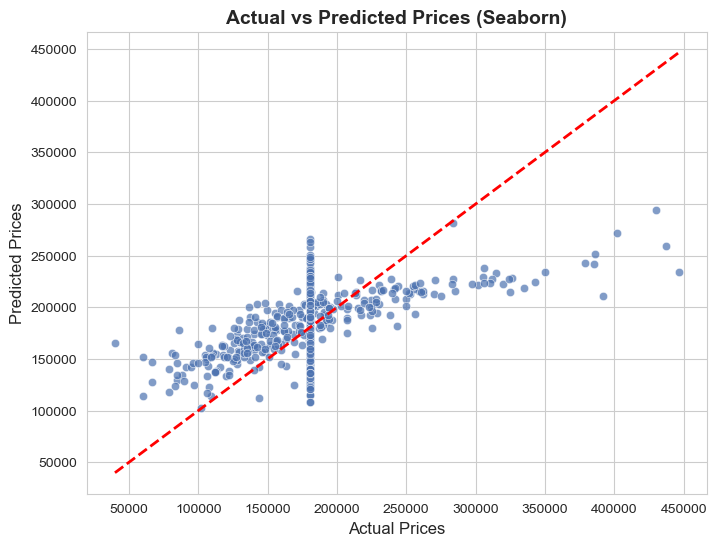

In [20]:
sns.set_style("whitegrid")   # clean background
sns.set_palette("deep") 

plt.figure(figsize=(8,6))

sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2)

plt.xlabel("Actual Prices", fontsize=12)
plt.ylabel("Predicted Prices", fontsize=12)
plt.title("Actual vs Predicted Prices (Seaborn)", fontsize=14, fontweight='bold')

plt.show()

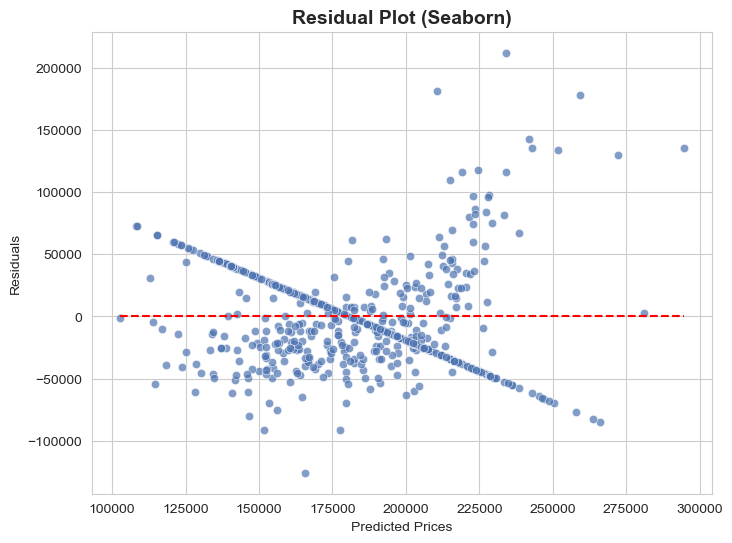

In [21]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

sns.scatterplot(x=y_pred, y=residuals, alpha=0.7)
sns.lineplot(x=y_pred, y=[0]*len(y_pred), color='red', linestyle='--')

plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")
plt.title("Residual Plot (Seaborn)", fontsize=14, fontweight='bold')

plt.show()

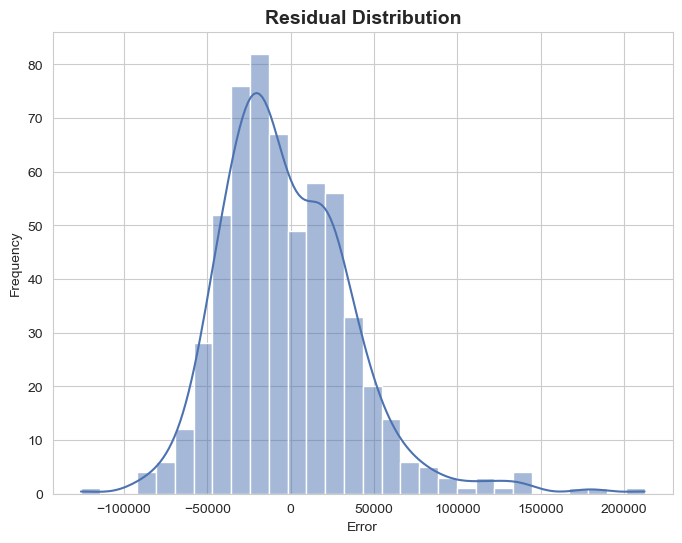

In [21]:
plt.figure(figsize=(8,6))

sns.histplot(residuals, kde=True, bins=30)

plt.title("Residual Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Error")
plt.ylabel("Frequency")

plt.show()

In [24]:
import numpy as np

X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()
y = y.loc[X.index]

In [25]:
import statsmodels.api as sm

# Convert features to numeric if required
X_numeric = X.astype(float)

# Add constant (intercept)
X_sm = sm.add_constant(X_numeric)

# Build regression model
model = sm.OLS(y, X_sm).fit()

# Display complete statistical summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.316
Model:                            OLS   Adj. R-squared:                  0.308
Method:                 Least Squares   F-statistic:                     40.29
Date:                Fri, 03 Apr 2026   Prob (F-statistic):          1.20e-209
Time:                        18:06:59   Log-Likelihood:                -35499.
No. Observations:                2918   AIC:                         7.107e+04
Df Residuals:                    2884   BIC:                         7.127e+04
Df Model:                          33                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                -1.37e+06   1

In [26]:
p_values = model.pvalues
print(p_values)

const                  3.955890e-28
MSSubClass             5.216543e-23
LotArea                3.179114e-14
OverallCond            1.072320e-03
YearBuilt              1.054548e-13
YearRemodAdd           1.196448e-07
BsmtFinSF2             4.009352e-02
TotalBsmtSF            3.681275e-64
MSZoning_FV            4.420858e-01
MSZoning_RH            3.306593e-01
MSZoning_RL            3.865306e-01
MSZoning_RM            3.129485e-01
LotConfig_CulDSac      2.254058e-01
LotConfig_FR2          5.912542e-01
LotConfig_FR3          7.980806e-01
LotConfig_Inside       8.008805e-01
BldgType_2fmCon        6.501459e-14
BldgType_Duplex        1.375598e-11
BldgType_Twnhs         1.091518e-14
BldgType_TwnhsE        1.212543e-21
Exterior1st_AsphShn    5.669099e-01
Exterior1st_BrkComm    1.922130e-01
Exterior1st_BrkFace    3.681775e-01
Exterior1st_CBlock     9.809490e-01
Exterior1st_CemntBd    9.691451e-01
Exterior1st_HdBoard    8.269229e-02
Exterior1st_ImStucc    3.662056e-01
Exterior1st_MetalSd    3.526

In [27]:
significant_features = p_values[p_values < 0.05]
print(significant_features)

const              3.955890e-28
MSSubClass         5.216543e-23
LotArea            3.179114e-14
OverallCond        1.072320e-03
YearBuilt          1.054548e-13
YearRemodAdd       1.196448e-07
BsmtFinSF2         4.009352e-02
TotalBsmtSF        3.681275e-64
BldgType_2fmCon    6.501459e-14
BldgType_Duplex    1.375598e-11
BldgType_Twnhs     1.091518e-14
BldgType_TwnhsE    1.212543e-21
dtype: float64
